# Linear Probe Model Comparison

Run the same model comparison as the frozen-feature kNN notebook, but replace kNN with a proper frozen-feature linear probe. This official comparison notebook does not reuse cached feature banks: every timed run extracts features, trains linear heads, evaluates checkpoints, and reports the work it actually performed. Compact CSV/JSON result tables can be saved; heavy feature tensors are not saved here.


In [1]:
import os

os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: /home/jovyan/xai/xai_for_medical_fm


In [2]:
import gc
import time
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from packaging.version import Version
from torch.utils.data import DataLoader

MIN_TRANSFORMERS_FOR_DINOV3 = Version("4.57.2")
if Version(transformers.__version__) < MIN_TRANSFORMERS_FOR_DINOV3:
    raise RuntimeError(
        "DINOv3 requires transformers>=4.57.2,<5 in this project. "
        "Run: python -m pip install -r ../requirements.txt "
        f"(current transformers={transformers.__version__})."
    )

from src.data import get_small_data
from src.model import extract_feature_bank, get_dino_backbone, model_metadata
from src.results import make_run_dir, save_linear_probe_outputs, validate_save_request
from src.train import make_linear_probe_grid, run_linear_probe_grid

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Transformers:", transformers.__version__)

def tensor_storage_mb(*tensors):
    return float(sum(tensor.numel() * tensor.element_size() for tensor in tensors) / 1024**2)


Device: cuda
Transformers: 4.57.6


## Config


In [3]:
dataset_name = "chestmnist"
data_fraction = 1.0
dataset_seed = 0
save_outputs = True

# Train each (lr, weight_decay) head once to max(checkpoint_epochs).
# Epoch choice is evaluated from checkpoints, not retrained as separate configs.
checkpoint_epochs = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]
train_grid = make_linear_probe_grid(
    lrs=[1e-4, 3e-4, 1e-3, 3e-3],
    weight_decays=[0.0, 1e-5, 1e-4, 1e-3],
)

# Thresholds are swept after each checkpoint without retraining.
thresholds = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5]
selection_metric = "mean_auc"

probe_batch_size = 512
normalize_features = True
output_root = project_root / "outputs"

model_configs = [
    {
        "run_name": "dinov2_small_224",
        "model_name": "facebook/dinov2-small",
        "image_size": 224,
        "batch_size": 32,
    },
    {
        "run_name": "dinov2_large_224",
        "model_name": "facebook/dinov2-large",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "dinov3_large_224",
        "model_name": "facebook/dinov3-vitl16-pretrain-lvd1689m",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "stanford_dinov2_xray_224",
        "model_name": "StanfordAIMI/dinov2-base-xray-224",
        "image_size": 224,
        "batch_size": 16,
    },
    {
        "run_name": "rad_dino_518",
        "model_name": "microsoft/rad-dino",
        "image_size": 518,
        "batch_size": 8,
    },
]

validate_save_request(save_outputs, data_fraction)
models_to_run = model_configs
print("linear heads trained per model:", len(train_grid))
print("epoch checkpoints per head:", len(checkpoint_epochs))
print("thresholds per checkpoint:", len(thresholds))
print("metric rows per model:", len(train_grid) * len(checkpoint_epochs) * len(thresholds))
models_to_run


linear heads trained per model: 16
epoch checkpoints per head: 18
thresholds per checkpoint: 12
metric rows per model: 3456


[{'run_name': 'dinov2_small_224',
  'model_name': 'facebook/dinov2-small',
  'image_size': 224,
  'batch_size': 32},
 {'run_name': 'dinov2_large_224',
  'model_name': 'facebook/dinov2-large',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'dinov3_large_224',
  'model_name': 'facebook/dinov3-vitl16-pretrain-lvd1689m',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'stanford_dinov2_xray_224',
  'model_name': 'StanfordAIMI/dinov2-base-xray-224',
  'image_size': 224,
  'batch_size': 16},
 {'run_name': 'rad_dino_518',
  'model_name': 'microsoft/rad-dino',
  'image_size': 518,
  'batch_size': 8}]

## Run Experiments


In [4]:
all_histories = []
all_trials = []
all_summaries = []
all_per_class = []
all_metadata = []

for config in tqdm(models_to_run, desc="Models", leave=True):
    run_start = time.perf_counter()
    run_name = config["run_name"]
    model_name = config["model_name"]
    image_size = config["image_size"]
    batch_size = config["batch_size"]

    print("=" * 80)
    print(run_name)
    print(model_name)

    context = {
        "dataset_name": dataset_name,
        "adaptation_method": "linear_probe",
        "run_name": run_name,
        "model_name": model_name,
        "image_size": image_size,
        "batch_size": batch_size,
        "probe_batch_size": probe_batch_size,
        "data_fraction": data_fraction,
        "dataset_seed": dataset_seed,
        "normalize_features": normalize_features,
    }

    data_start = time.perf_counter()
    train_loader, val_loader, class_names = get_small_data(
        batch_size=batch_size,
        image_size=image_size,
        data_fraction=data_fraction,
        seed=dataset_seed,
    )
    data_load_seconds = time.perf_counter() - data_start

    train_feature_loader = DataLoader(
        train_loader.dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )
    val_feature_loader = DataLoader(
        val_loader.dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    model_start = time.perf_counter()
    backbone = get_dino_backbone(model_name).to(device)
    backbone_metadata = model_metadata(backbone)
    model_load_seconds = time.perf_counter() - model_start
    print("total params:", f"{backbone_metadata['total_params']:,}")
    print("trainable params:", f"{backbone_metadata['trainable_params']:,}")

    feature_bank, feature_metadata = extract_feature_bank(
        backbone,
        train_feature_loader,
        val_feature_loader,
        device,
        class_names=class_names,
        normalize=normalize_features,
    )
    feature_metadata = {**feature_metadata, **backbone_metadata}
    feature_storage_mb = tensor_storage_mb(
        feature_bank["train_features"],
        feature_bank["val_features"],
    )

    del backbone
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    result = run_linear_probe_grid(
        feature_bank=feature_bank,
        device=device,
        class_names=class_names,
        train_grid=train_grid,
        checkpoint_epochs=checkpoint_epochs,
        thresholds=thresholds,
        batch_size=probe_batch_size,
        selection_metric=selection_metric,
        seed=dataset_seed,
        backbone_metadata=backbone_metadata,
        context=context,
        show_progress=True,
    )

    feature_peak_gpu_memory_mb = feature_metadata.get("peak_gpu_memory_mb")
    probe_peak_gpu_memory_mb = result["metadata"].get("peak_gpu_memory_mb")
    peak_values = [value for value in [feature_peak_gpu_memory_mb, probe_peak_gpu_memory_mb] if value is not None]

    feature_extraction_seconds = float(feature_metadata["feature_extraction_seconds"])
    adaptation_seconds = float(result["metadata"]["head_train_grid_seconds"])
    inference_or_eval_seconds = float(result["metadata"]["val_eval_grid_seconds"])
    threshold_search_seconds = float(result["metadata"]["threshold_search_grid_seconds"])
    efficiency_counted_seconds = float(
        feature_extraction_seconds
        + adaptation_seconds
        + inference_or_eval_seconds
        + threshold_search_seconds
    )
    actual_wall_seconds = float(time.perf_counter() - run_start)

    metadata = {
        **result["metadata"],
        "data_load_seconds": float(data_load_seconds),
        "model_load_seconds": float(model_load_seconds),
        "feature_extraction_seconds": feature_extraction_seconds,
        "train_feature_seconds": float(feature_metadata["train_feature_seconds"]),
        "val_feature_seconds": float(feature_metadata["val_feature_seconds"]),
        "adaptation_seconds": adaptation_seconds,
        "inference_or_eval_seconds": inference_or_eval_seconds,
        "threshold_search_seconds": threshold_search_seconds,
        "efficiency_counted_seconds": efficiency_counted_seconds,
        "actual_wall_seconds": actual_wall_seconds,
        "feature_dim": int(feature_bank["train_features"].shape[1]),
        "train_samples": int(feature_bank["train_features"].shape[0]),
        "val_samples": int(feature_bank["val_features"].shape[0]),
        "feature_storage_mb": feature_storage_mb,
        "feature_peak_gpu_memory_mb": feature_peak_gpu_memory_mb,
        "peak_gpu_memory_mb": max(peak_values) if peak_values else None,
        "shortcut_used": False,
    }

    result_run_dir = make_run_dir(
        output_root,
        dataset_name,
        f"linear_probe/{run_name}",
        data_fraction=data_fraction,
        dataset_seed=dataset_seed,
    )

    if save_outputs:
        save_linear_probe_outputs(
            result_run_dir,
            history_df=result["history"],
            summary_df=result["summary"],
            per_class_df=result["per_class"],
            trials_df=result["trials"],
            metadata=metadata,
        )

    all_histories.append(result["history"])
    all_trials.append(result["trials"])
    all_summaries.append(result["summary"])
    all_per_class.append(result["per_class"])
    all_metadata.append(metadata)

    del feature_bank
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

combined_history_df = pd.concat(all_histories, ignore_index=True)
combined_trials_df = pd.concat(all_trials, ignore_index=True)
selected_summary_df = pd.concat(all_summaries, ignore_index=True)
selected_per_class_df = pd.concat(all_per_class, ignore_index=True)
metadata_df = pd.DataFrame(all_metadata)

selected_summary_df


Models:   0%|          | 0/5 [00:00<?, ?it/s]

dinov2_small_224
facebook/dinov2-small
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
Using downloaded and verified file: /home/jovyan/.medmnist/chestmnist.npz
total params: 22,056,576
trainable params: 0


Linear probe configs:   0%|          | 0/16 [00:00<?, ?it/s]

Feature probe epoch 1/100:   0%|          | 0/154 [00:00<?, ?it/s]

Feature probe epoch 2/100:   0%|          | 0/154 [00:00<?, ?it/s]

...

Feature probe epoch 1/100:   0%|          | 0/154 [00:00<?, ?it/s]

Feature probe epoch 2/100:   0%|          | 0/154 [00:00<?, ?it/s]

Feature probe epoch 3/100:   0%|          | 0/154 [00:00<?, ?it/s]

Feature probe epoch 4/100:   0%|          | 0/154 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Reporting Policy

Use one validation-selected row per model as the headline comparison. Mean AUROC selects the checkpoint/configuration; macro F1 breaks AUROC ties to choose the operating threshold. Report the chosen checkpoint `epoch`, `lr`, `weight_decay`, and `threshold` next to the metrics. Do not headline an average over all grid settings or thresholds; those rows are the search space, not repeated estimates of one setting. Use grid distributions and checkpoint curves as robustness/audit evidence.


## Visualize Model Comparison


In [5]:
display_names = {
    "dinov2_small_224": "DINOv2-S 224",
    "dinov2_large_224": "DINOv2-L 224",
    "dinov3_large_224": "DINOv3-L 224",
    "stanford_dinov2_xray_224": "Stanford X-ray DINOv2-B 224",
    "rad_dino_518": "RAD-DINO 518",
}

model_groups = {
    "dinov2_small_224": "Generic DINOv2",
    "dinov2_large_224": "Generic DINOv2",
    "dinov3_large_224": "Generic DINOv3",
    "stanford_dinov2_xray_224": "Medical/X-ray",
    "rad_dino_518": "Medical/X-ray",
}

group_colors = {
    "Generic DINOv2": "tab:blue",
    "Generic DINOv3": "tab:purple",
    "Medical/X-ray": "tab:green",
}

plot_summary_df = selected_summary_df.copy()
plot_summary_df["display_name"] = plot_summary_df["run_name"].map(display_names).fillna(plot_summary_df["run_name"].str.replace("_", " "))
plot_summary_df["model_group"] = plot_summary_df["run_name"].map(model_groups).fillna("Other")

plot_trials_df = combined_trials_df.copy()
plot_trials_df["display_name"] = plot_trials_df["run_name"].map(display_names).fillna(plot_trials_df["run_name"].str.replace("_", " "))
plot_trials_df["model_group"] = plot_trials_df["run_name"].map(model_groups).fillna("Other")

plot_metadata_df = metadata_df.copy()
plot_metadata_df["display_name"] = plot_metadata_df["run_name"].map(display_names).fillna(plot_metadata_df["run_name"].str.replace("_", " "))
plot_metadata_df["model_group"] = plot_metadata_df["run_name"].map(model_groups).fillna("Other")

plot_per_class_df = selected_per_class_df.copy()
plot_per_class_df["display_name"] = plot_per_class_df["run_name"].map(display_names).fillna(plot_per_class_df["run_name"].str.replace("_", " "))
plot_per_class_df["model_group"] = plot_per_class_df["run_name"].map(model_groups).fillna("Other")


### Checkpoint Curves by Model


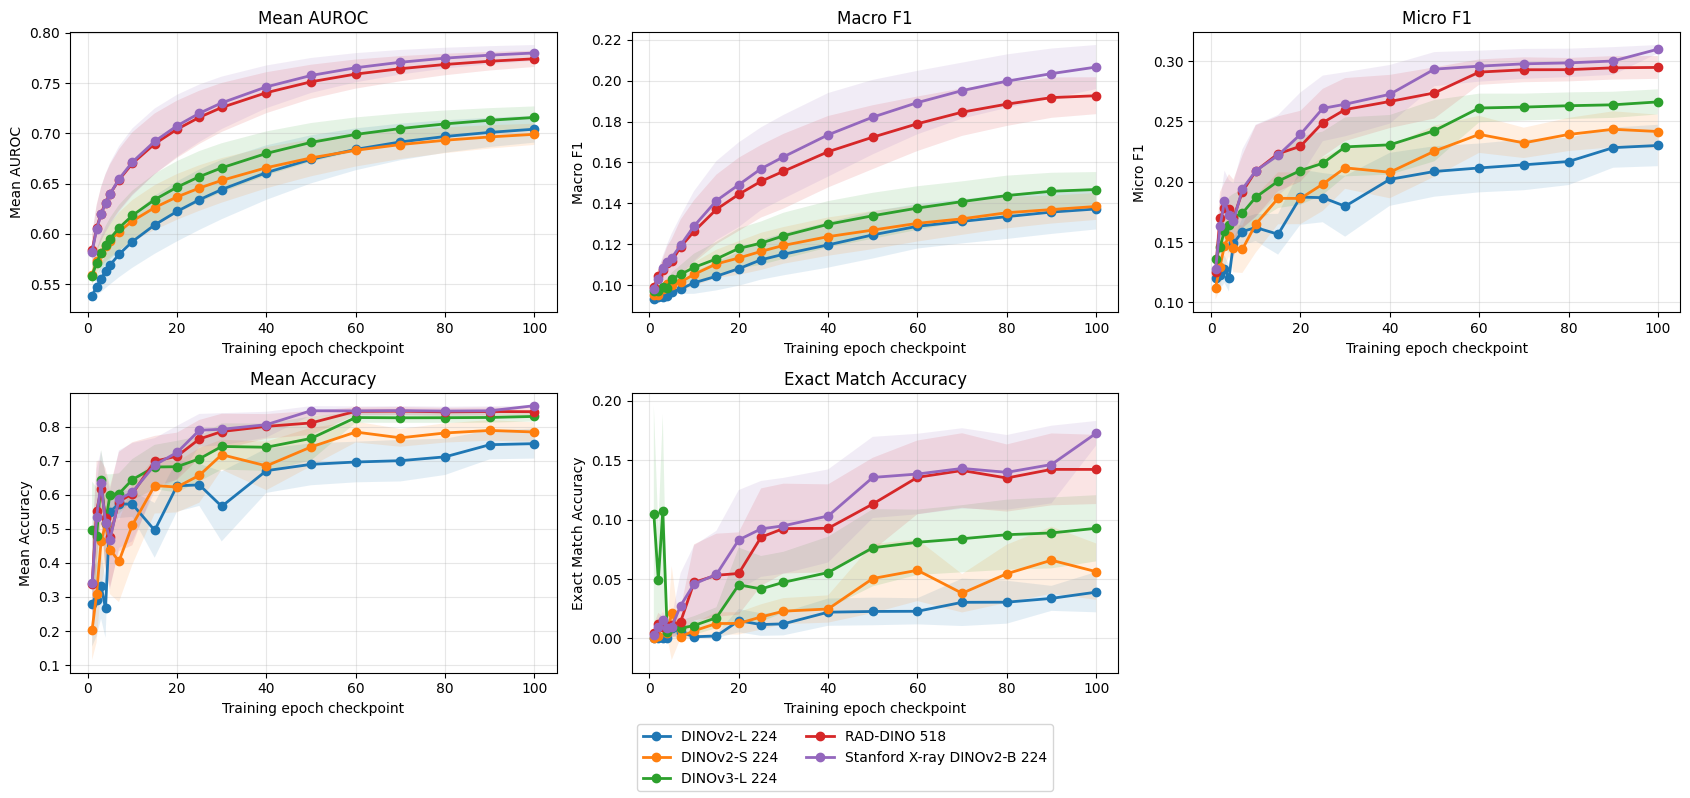

In [6]:
metrics_to_plot = [
    ("mean_auc", "Mean AUROC"),
    ("f1_macro", "Macro F1"),
    ("f1_micro", "Micro F1"),
    ("mean_accuracy", "Mean Accuracy"),
    ("exact_match_accuracy", "Exact Match Accuracy"),
]

# For each trained head and epoch checkpoint, keep its best threshold.
checkpoint_best_df = (
    plot_trials_df.sort_values(["run_name", "train_trial_id", "epoch", selection_metric], ascending=[True, True, True, False])
    .groupby(["run_name", "train_trial_id", "epoch"], as_index=False)
    .head(1)
)

checkpoint_curve_df = (
    checkpoint_best_df.groupby(["display_name", "model_group", "epoch"], sort=False)
    .agg(
        runs=("train_trial_id", "nunique"),
        mean_auc_mean=("mean_auc", "mean"),
        mean_auc_std=("mean_auc", "std"),
        f1_macro_mean=("f1_macro", "mean"),
        f1_macro_std=("f1_macro", "std"),
        f1_micro_mean=("f1_micro", "mean"),
        f1_micro_std=("f1_micro", "std"),
        mean_accuracy_mean=("mean_accuracy", "mean"),
        mean_accuracy_std=("mean_accuracy", "std"),
        exact_match_accuracy_mean=("exact_match_accuracy", "mean"),
        exact_match_accuracy_std=("exact_match_accuracy", "std"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.ravel()

for ax, (metric_col, title) in zip(axes, metrics_to_plot):
    mean_col = f"{metric_col}_mean"
    std_col = f"{metric_col}_std"
    for display_name, group_df in checkpoint_curve_df.groupby("display_name", sort=False):
        group_df = group_df.sort_values("epoch")
        x = group_df["epoch"].astype(float).to_numpy()
        y = group_df[mean_col].astype(float).to_numpy()

        ax.plot(x, y, marker="o", linewidth=2, label=display_name)

        if std_col in group_df and group_df[std_col].notna().any():
            std = group_df[std_col].astype(float).fillna(0).to_numpy()
            runs = group_df["runs"].astype(float).to_numpy()
            ci95 = 1.96 * std / np.sqrt(runs)
            ax.fill_between(x, y - ci95, y + ci95, alpha=0.12)

    ax.set_xlabel("Training epoch checkpoint")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[-1].axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=2)
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### Selected Full-Data Metrics


/tmp/ipykernel_2268/3826881716.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_values, labels=model_order, showmeans=True)
/tmp/ipykernel_2268/3826881716.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_values, labels=model_order, showmeans=True)


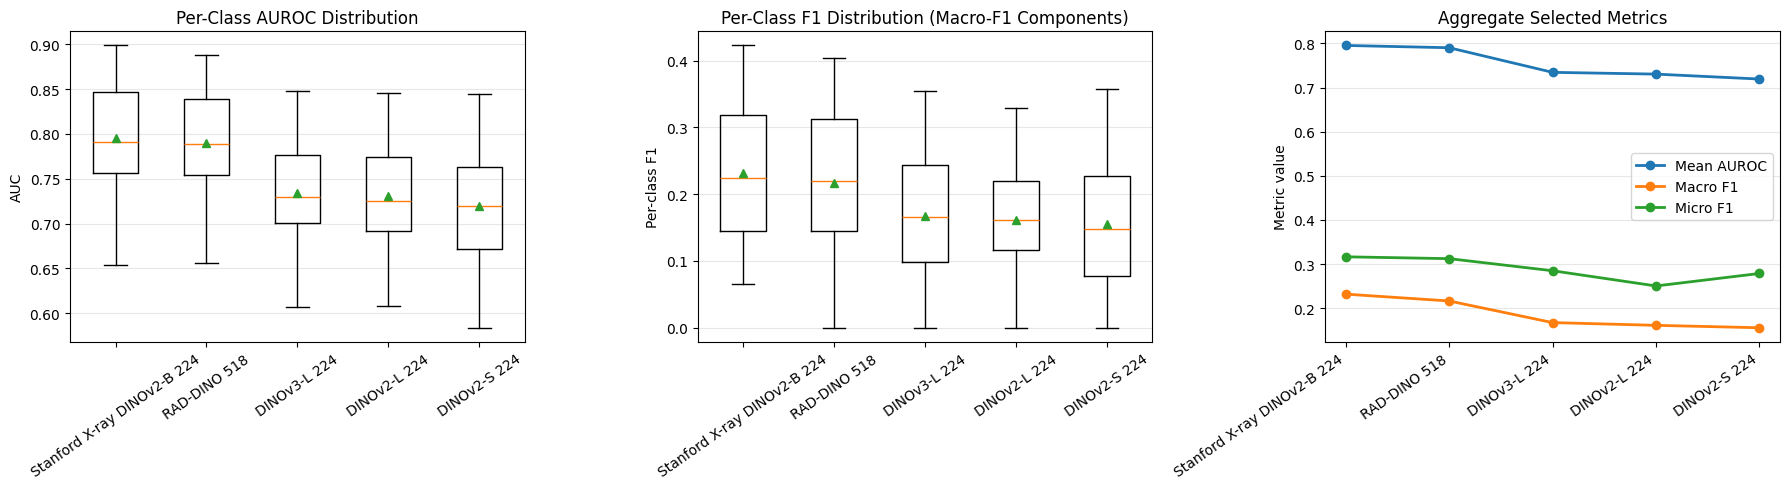

,display_name,model_name,image_size,epoch,lr,weight_decay,threshold,mean_auc,f1_macro,f1_micro,mean_accuracy,exact_match_accuracy
3,Stanford X-ray DINOv2-B 224,StanfordAIMI/dinov2-base-xray-224,224,100,0.003,0.00001,0.10,0.795279,0.231865,0.316446,0.862472,0.200285
4,RAD-DINO 518,microsoft/rad-dino,518,90,0.003,0.00010,0.10,0.790089,0.216366,0.312259,0.862663,0.203138
2,DINOv3-L 224,facebook/dinov3-vitl16-pretrain-lvd1689m,224,70,0.003,0.00010,0.10,0.734347,0.167396,0.284891,0.853100,0.159818
1,DINOv2-L 224,facebook/dinov2-large,224,100,0.003,0.00100,0.07,0.730337,0.161204,0.250414,0.795239,0.056690
0,DINOv2-S 224,facebook/dinov2-small,224,100,0.003,0.00000,0.10,0.719180,0.155708,0.278667,0.854017,0.133702


In [7]:
full_plot_df = plot_summary_df.copy()
full_plot_df = full_plot_df.sort_values("mean_auc", ascending=False)
model_order = full_plot_df["display_name"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

box_specs = [
    ("auc", "Per-Class AUROC Distribution"),
    ("f1", "Per-Class F1 Distribution (Macro-F1 Components)"),
]

for ax, (value_col, title) in zip(axes[:2], box_specs):
    box_values = [
        plot_per_class_df.loc[plot_per_class_df["display_name"] == name, value_col].dropna().to_numpy()
        for name in model_order
    ]
    ax.boxplot(box_values, labels=model_order, showmeans=True)
    ax.set_title(title)
    ax.set_ylabel(value_col.upper() if value_col == "auc" else "Per-class F1")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, axis="y", alpha=0.3)

aggregate_metrics = [
    ("mean_auc", "Mean AUROC"),
    ("f1_macro", "Macro F1"),
    ("f1_micro", "Micro F1"),
]
x = np.arange(len(model_order))
for metric_col, label in aggregate_metrics:
    y = full_plot_df.set_index("display_name").loc[model_order, metric_col].to_numpy()
    axes[2].plot(x, y, marker="o", linewidth=2, label=label)

axes[2].set_xticks(x)
axes[2].set_xticklabels(model_order, rotation=35, ha="right")
axes[2].set_title("Aggregate Selected Metrics")
axes[2].set_ylabel("Metric value")
axes[2].grid(True, axis="y", alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

full_plot_df[
    [
        "display_name",
        "model_name",
        "image_size",
        "epoch",
        "lr",
        "weight_decay",
        "threshold",
        "mean_auc",
        "f1_macro",
        "f1_micro",
        "mean_accuracy",
        "exact_match_accuracy",
    ]
]


### Efficiency vs Performance


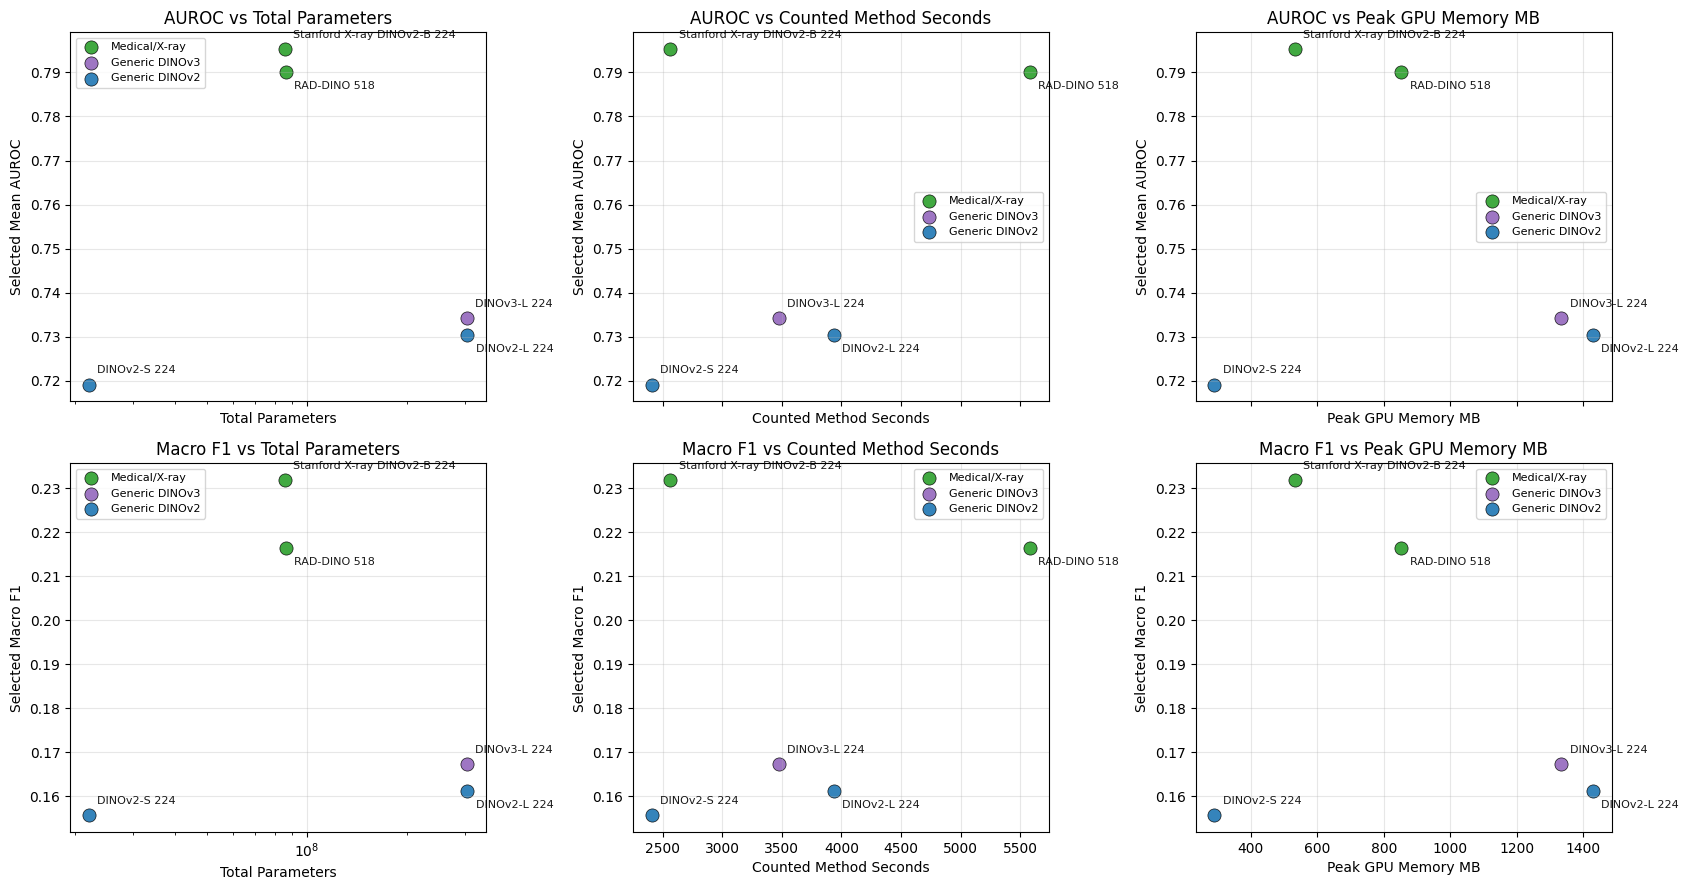

,run_name,model_group,mean_auc,f1_macro,f1_micro,total_params,trainable_params,feature_dim,feature_storage_mb,feature_extraction_seconds,adaptation_seconds,inference_or_eval_seconds,threshold_search_seconds,efficiency_counted_seconds,actual_wall_seconds,peak_gpu_memory_mb,shortcut_used
0,stanford_dinov2_xray_224,Medical/X-ray,0.795279,0.231865,0.316446,85736462,10766,768,262.754883,542.725509,1309.717230,326.329949,1.372927,2565.259578,3730.824554,533.207031,False
1,rad_dino_518,Medical/X-ray,0.790089,0.216366,0.312259,86591246,10766,768,262.754883,3555.353408,1312.373551,327.675739,1.344172,5579.233771,6742.395618,852.996582,False
2,dinov3_large_224,Generic DINOv3,0.734347,0.167396,0.284891,303143950,14350,1024,350.339844,1413.694042,1341.511145,338.178100,1.329103,3476.935769,4629.586975,1333.445801,False
3,dinov2_large_224,Generic DINOv2,0.730337,0.161204,0.250414,304382990,14350,1024,350.339844,1879.042324,1337.438334,334.689348,1.342326,3934.074088,5088.123292,1427.511719,False
4,dinov2_small_224,Generic DINOv2,0.719180,0.155708,0.278667,22061966,5390,384,131.377441,256.011025,1420.507912,343.948532,1.358948,2409.883950,3597.922648,291.389160,False


In [8]:
efficiency_df = full_plot_df.merge(
    plot_metadata_df,
    on=["dataset_name", "run_name", "model_name", "image_size", "display_name", "model_group"],
    how="left",
    suffixes=("", "_metadata"),
)

fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex="col")

scatter_specs = [
    ("total_params", "Total Parameters", True),
    ("efficiency_counted_seconds", "Counted Method Seconds", False),
    ("peak_gpu_memory_mb", "Peak GPU Memory MB", False),
]
metric_specs = [
    ("mean_auc", "Selected Mean AUROC", "AUROC"),
    ("f1_macro", "Selected Macro F1", "Macro F1"),
]

for row_idx, (metric_col, y_label, metric_title) in enumerate(metric_specs):
    for ax, (x_col, x_label, log_x) in zip(axes[row_idx], scatter_specs):
        plot_df = efficiency_df.dropna(subset=[x_col, metric_col])
        for model_group, group_df in plot_df.groupby("model_group", sort=False):
            ax.scatter(
                group_df[x_col],
                group_df[metric_col],
                s=90,
                color=group_colors.get(model_group, "tab:gray"),
                label=model_group,
                alpha=0.9,
                edgecolor="black",
                linewidth=0.5,
            )

        for idx, (_, row) in enumerate(plot_df.iterrows()):
            offset_y = 8 if idx % 2 == 0 else -12
            ax.annotate(
                row["display_name"],
                (row[x_col], row[metric_col]),
                textcoords="offset points",
                xytext=(6, offset_y),
                fontsize=8,
                alpha=0.9,
            )

        if log_x:
            ax.set_xscale("log")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(f"{metric_title} vs {x_label}")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

efficiency_df[
    [
        "run_name",
        "model_group",
        "mean_auc",
        "f1_macro",
        "f1_micro",
        "total_params",
        "trainable_params",
        "feature_dim",
        "feature_storage_mb",
        "feature_extraction_seconds",
        "adaptation_seconds",
        "inference_or_eval_seconds",
        "threshold_search_seconds",
        "efficiency_counted_seconds",
        "actual_wall_seconds",
        "peak_gpu_memory_mb",
        "shortcut_used",
    ]
]


### Per-Class Selected Diagnostics


In [9]:
per_class_table_df = plot_per_class_df[
    [
        "display_name",
        "class_name",
        "true_positive_rate",
        "predicted_positive_rate",
        "accuracy",
        "f1",
        "auc",
    ]
].sort_values(["display_name", "class_name"])

per_class_table_df


,display_name,class_name,true_positive_rate,predicted_positive_rate,accuracy,f1,auc
14,DINOv2-L 224,atelectasis,0.099742,0.556199,0.508780,0.251121,0.724364
15,DINOv2-L 224,cardiomegaly,0.021392,0.051431,0.938586,0.156671,0.775570
22,DINOv2-L 224,consolidation,0.039843,0.180943,0.818076,0.176019,0.768032
23,DINOv2-L 224,edema,0.017827,0.072823,0.923612,0.157325,0.845299
16,DINOv2-L 224,effusion,0.115162,0.476780,0.603084,0.329468,0.790032
...,...,...,...,...,...,...,...
46,Stanford X-ray DINOv2-B 224,mass,0.055709,0.131473,0.871825,0.315238,0.809898
47,Stanford X-ray DINOv2-B 224,nodule,0.054639,0.108655,0.865942,0.179039,0.653371
54,Stanford X-ray DINOv2-B 224,pleural,0.033158,0.050094,0.934397,0.211991,0.781828
48,Stanford X-ray DINOv2-B 224,pneumonia,0.011855,0.005883,0.983510,0.070352,0.741806


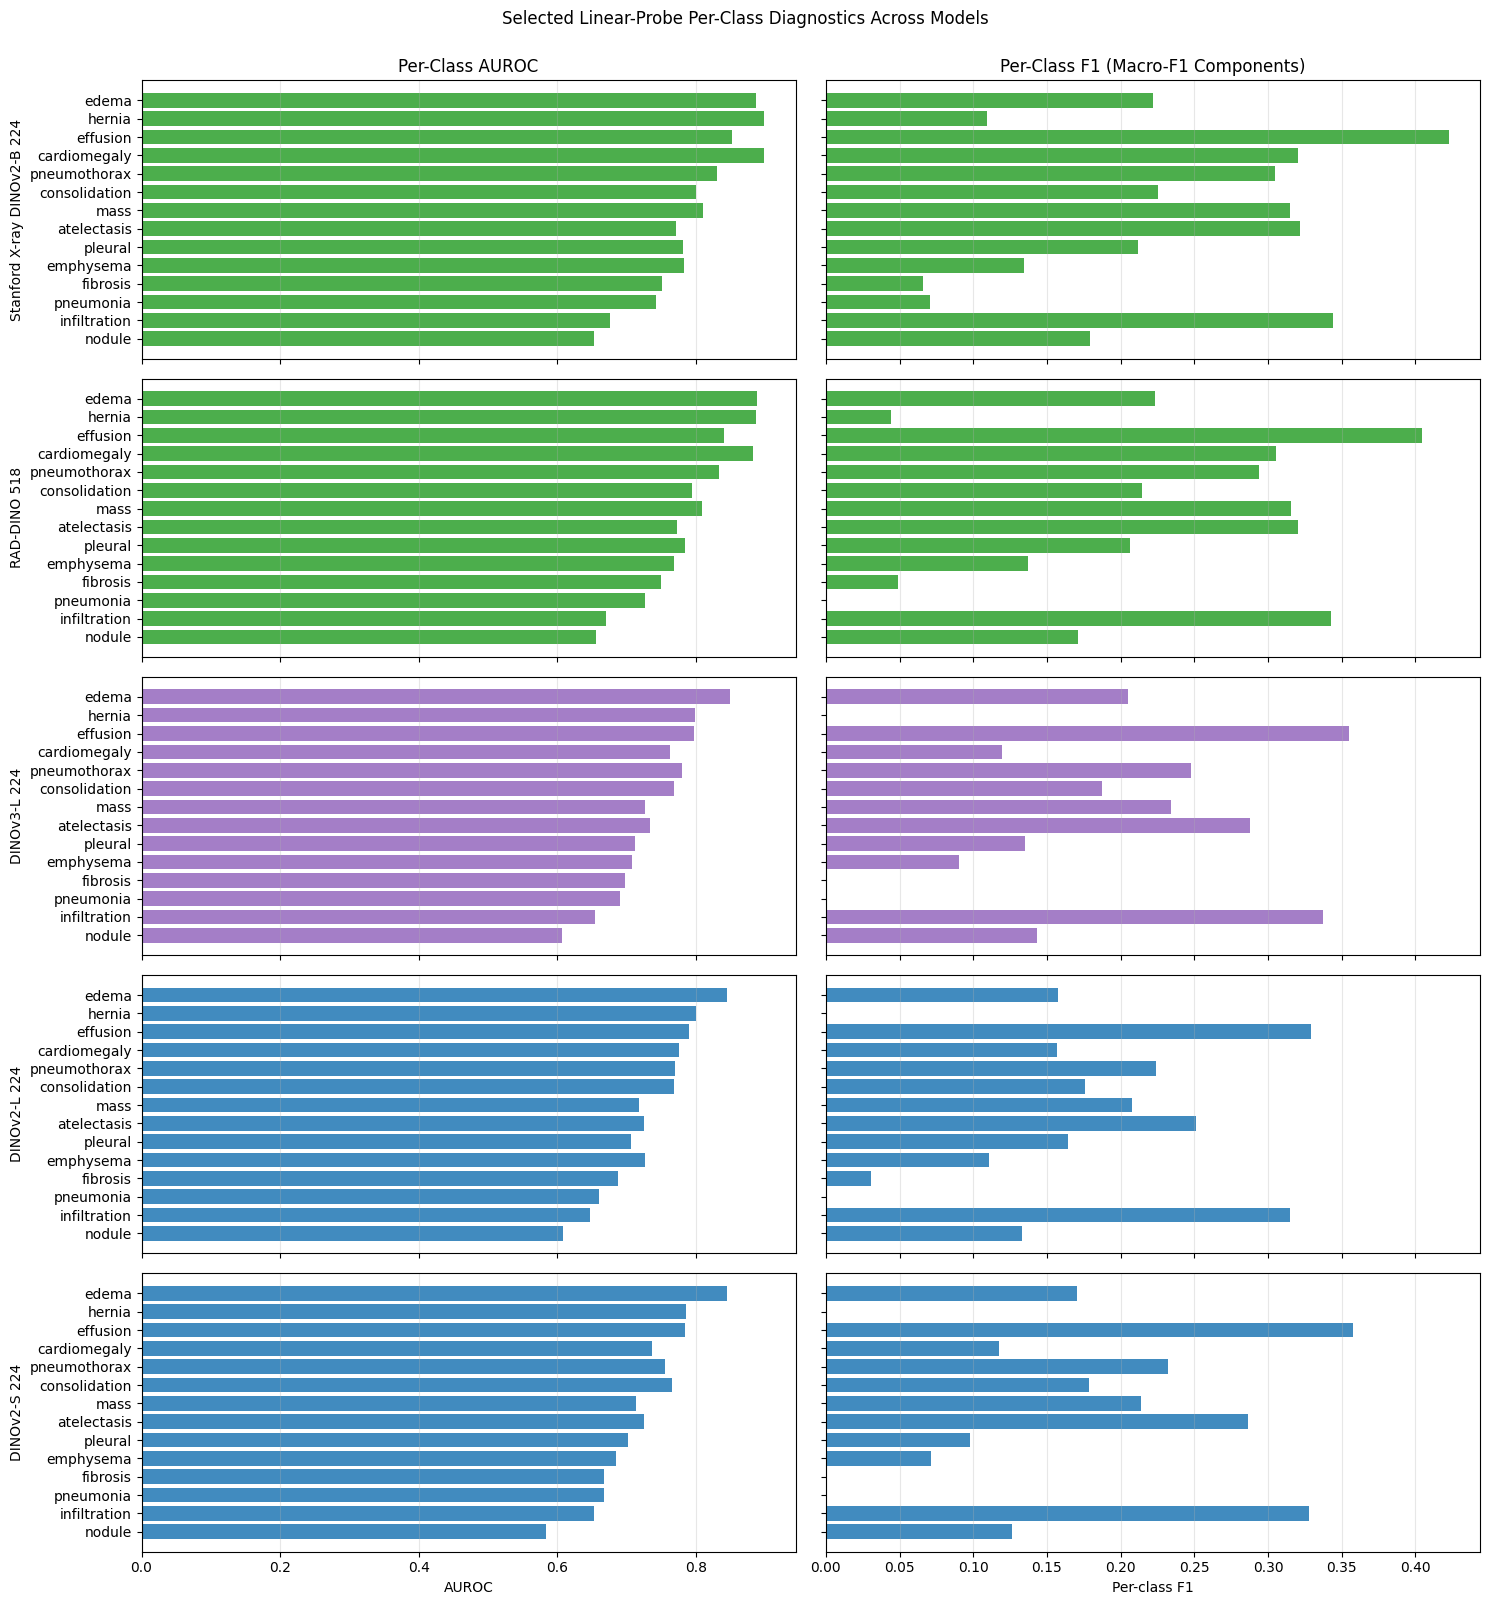

In [10]:
if not plot_per_class_df.empty:
    class_order = (
        plot_per_class_df.groupby("class_name")["auc"]
        .mean()
        .sort_values(ascending=True)
        .index
        .tolist()
    )
    model_order = [name for name in model_order if name in plot_per_class_df["display_name"].unique()]

    fig, axes = plt.subplots(
        len(model_order),
        2,
        figsize=(15, 3.2 * len(model_order)),
        sharex="col",
        sharey=True,
    )
    axes = np.atleast_2d(axes)

    for row_idx, display_name in enumerate(model_order):
        model_df = plot_per_class_df[plot_per_class_df["display_name"] == display_name]
        model_df = model_df.set_index("class_name").loc[class_order].reset_index()

        color = group_colors.get(model_df["model_group"].iloc[0], "tab:gray")
        axes[row_idx, 0].barh(model_df["class_name"], model_df["auc"], color=color, alpha=0.85)
        axes[row_idx, 1].barh(model_df["class_name"], model_df["f1"], color=color, alpha=0.85)

        axes[row_idx, 0].set_ylabel(display_name)
        axes[row_idx, 0].grid(True, axis="x", alpha=0.3)
        axes[row_idx, 1].grid(True, axis="x", alpha=0.3)

    axes[0, 0].set_title("Per-Class AUROC")
    axes[0, 1].set_title("Per-Class F1 (Macro-F1 Components)")
    axes[-1, 0].set_xlabel("AUROC")
    axes[-1, 1].set_xlabel("Per-class F1")
    fig.suptitle("Selected Linear-Probe Per-Class Diagnostics Across Models", y=1.0)
    plt.tight_layout()
    plt.show()


## Report-Ready Table


In [11]:
report_table_df = full_plot_df.merge(
    plot_metadata_df[[
        "run_name",
        "selection_metric",
        "num_train_trials",
        "num_epoch_checkpoints",
        "num_thresholds",
        "feature_dim",
        "train_samples",
        "val_samples",
        "total_params",
        "trainable_params",
        "trainable_param_fraction",
        "feature_storage_mb",
        "feature_extraction_seconds",
        "adaptation_seconds",
        "inference_or_eval_seconds",
        "threshold_search_grid_seconds",
        "efficiency_counted_seconds",
        "actual_wall_seconds",
        "peak_gpu_memory_mb",
        "shortcut_used",
    ]],
    on="run_name",
    how="left",
)

report_cols = [
    "display_name",
    "mean_auc",
    "f1_macro",
    "f1_micro",
    "mean_accuracy",
    "exact_match_accuracy",
    "epoch",
    "lr",
    "weight_decay",
    "threshold",
    "selection_metric",
    "num_train_trials",
    "num_epoch_checkpoints",
    "num_thresholds",
    "total_params",
    "trainable_params",
    "trainable_param_fraction",
    "feature_storage_mb",
    "feature_extraction_seconds",
    "adaptation_seconds",
    "inference_or_eval_seconds",
    "threshold_search_grid_seconds",
    "efficiency_counted_seconds",
    "actual_wall_seconds",
    "peak_gpu_memory_mb",
    "shortcut_used",
]

report_table_df[report_cols].sort_values(selection_metric, ascending=False)


,display_name,mean_auc,f1_macro,f1_micro,mean_accuracy,exact_match_accuracy,epoch,lr,weight_decay,threshold,...,trainable_param_fraction,feature_storage_mb,feature_extraction_seconds,adaptation_seconds,inference_or_eval_seconds,threshold_search_grid_seconds,efficiency_counted_seconds,actual_wall_seconds,peak_gpu_memory_mb,shortcut_used
0,Stanford X-ray DINOv2-B 224,0.795279,0.231865,0.316446,0.862472,0.200285,100,0.003,0.00001,0.10,...,0.000126,262.754883,542.725509,1309.717230,326.329949,386.486891,2565.259578,3730.824554,533.207031,False
1,RAD-DINO 518,0.790089,0.216366,0.312259,0.862663,0.203138,90,0.003,0.00010,0.10,...,0.000124,262.754883,3555.353408,1312.373551,327.675739,383.831073,5579.233771,6742.395618,852.996582,False
2,DINOv3-L 224,0.734347,0.167396,0.284891,0.853100,0.159818,70,0.003,0.00010,0.10,...,0.000047,350.339844,1413.694042,1341.511145,338.178100,383.552481,3476.935769,4629.586975,1333.445801,False
3,DINOv2-L 224,0.730337,0.161204,0.250414,0.795239,0.056690,100,0.003,0.00100,0.07,...,0.000047,350.339844,1879.042324,1337.438334,334.689348,382.904081,3934.074088,5088.123292,1427.511719,False
4,DINOv2-S 224,0.719180,0.155708,0.278667,0.854017,0.133702,100,0.003,0.00000,0.10,...,0.000244,131.377441,256.011025,1420.507912,343.948532,389.416481,2409.883950,3597.922648,291.389160,False


## Linear-Probe Hyperparameter Robustness


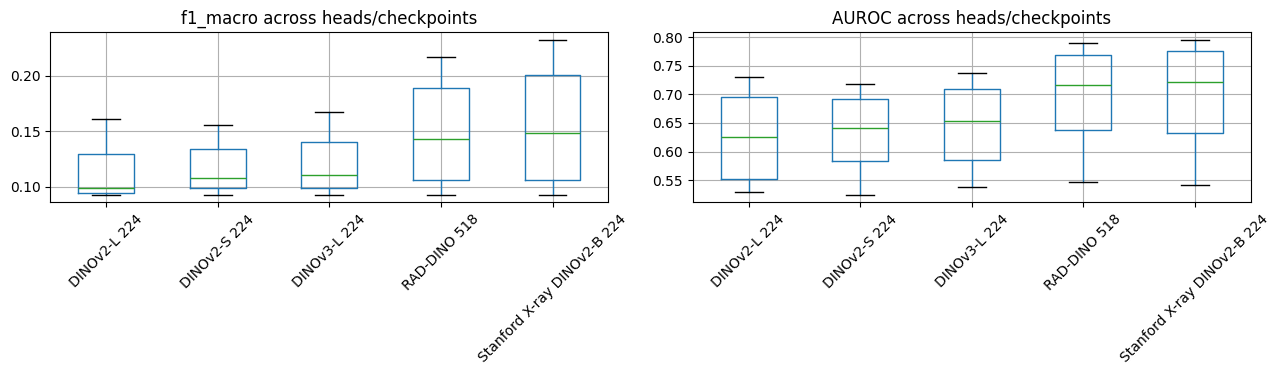

In [12]:
# Each box summarizes trained heads/checkpoints after choosing the best threshold for that checkpoint.
best_threshold_per_checkpoint_df = (
    plot_trials_df.sort_values(["run_name", "train_trial_id", "epoch", selection_metric], ascending=[True, True, True, False])
    .groupby(["run_name", "train_trial_id", "epoch"], as_index=False)
    .head(1)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
best_threshold_per_checkpoint_df.boxplot(column=selection_metric, by="display_name", ax=axes[0], rot=45)
best_threshold_per_checkpoint_df.boxplot(column="mean_auc", by="display_name", ax=axes[1], rot=45)
axes[0].set_title(f"{selection_metric} across heads/checkpoints")
axes[1].set_title("AUROC across heads/checkpoints")
axes[0].set_xlabel("")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()


## Trial Table


In [13]:
trial_cols = [
    "display_name",
    "train_trial_id",
    "trial_id",
    "epoch",
    "lr",
    "weight_decay",
    "threshold",
    "mean_auc",
    "f1_macro",
    "f1_micro",
    "mean_accuracy",
    "loss",
]
plot_trials_df[trial_cols].sort_values(["display_name", selection_metric], ascending=[True, False])


,display_name,train_trial_id,trial_id,epoch,lr,weight_decay,threshold,mean_auc,f1_macro,f1_micro,mean_accuracy,loss
6906,DINOv2-L 224,train_trial_015,train_trial_015_epoch_100,100,0.003,0.00100,0.07,0.730337,0.161204,0.250414,0.795239,0.165869
6894,DINOv2-L 224,train_trial_015,train_trial_015_epoch_090,90,0.003,0.00100,0.07,0.729896,0.160215,0.251181,0.797136,0.165993
6907,DINOv2-L 224,train_trial_015,train_trial_015_epoch_100,100,0.003,0.00100,0.10,0.730337,0.160132,0.277830,0.859034,0.165869
6462,DINOv2-L 224,train_trial_013,train_trial_013_epoch_090,90,0.003,0.00001,0.07,0.730102,0.159772,0.250139,0.794596,0.165825
6475,DINOv2-L 224,train_trial_013,train_trial_013_epoch_100,100,0.003,0.00001,0.10,0.730271,0.159412,0.277488,0.854615,0.165780
...,...,...,...,...,...,...,...,...,...,...,...,...
12779,Stanford X-ray DINOv2-B 224,train_trial_011,train_trial_011_epoch_003,3,0.001,0.00100,0.50,0.633262,0.000000,0.000000,0.949193,0.177985
12971,Stanford X-ray DINOv2-B 224,train_trial_012,train_trial_012_epoch_001,1,0.003,0.00000,0.50,0.629672,0.000000,0.000000,0.949193,0.177222
13187,Stanford X-ray DINOv2-B 224,train_trial_013,train_trial_013_epoch_001,1,0.003,0.00001,0.50,0.629958,0.000000,0.000000,0.949206,0.177340
13403,Stanford X-ray DINOv2-B 224,train_trial_014,train_trial_014_epoch_001,1,0.003,0.00010,0.50,0.633012,0.000000,0.000000,0.949193,0.177073


## Training Curves For Selected Heads


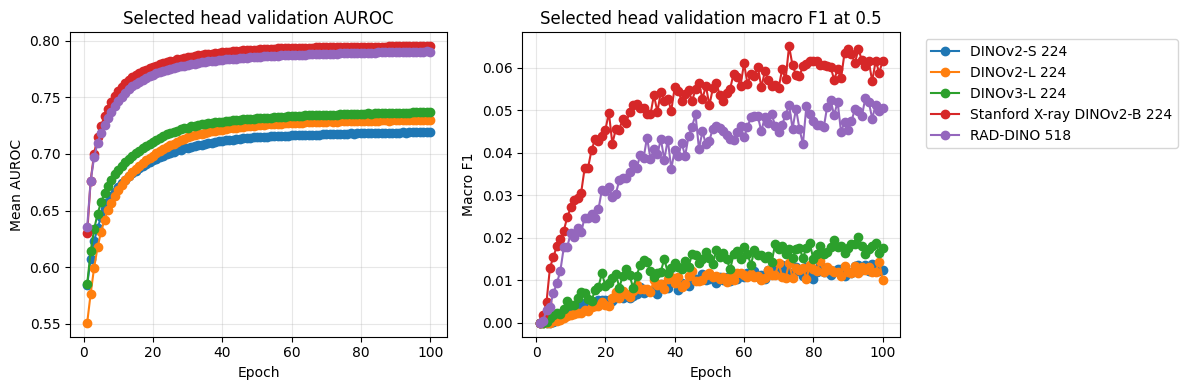

In [14]:
selected_train_ids = full_plot_df[["run_name", "train_trial_id"]].drop_duplicates()
selected_history_df = combined_history_df.merge(selected_train_ids, on=["run_name", "train_trial_id"], how="inner")
selected_history_df["display_name"] = selected_history_df["run_name"].map(display_names).fillna(selected_history_df["run_name"].str.replace("_", " "))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for display_name, group in selected_history_df.groupby("display_name", sort=False):
    axes[0].plot(group["epoch"], group["val_mean_auc"], marker="o", label=display_name)
    axes[1].plot(group["epoch"], group["val_f1_macro"], marker="o", label=display_name)

axes[0].set_title("Selected head validation AUROC")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean AUROC")
axes[1].set_title("Selected head validation macro F1 at 0.5")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
for axis in axes:
    axis.grid(True, alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
